In [1]:
import numpy as np
import matplotlib.pyplot as plt

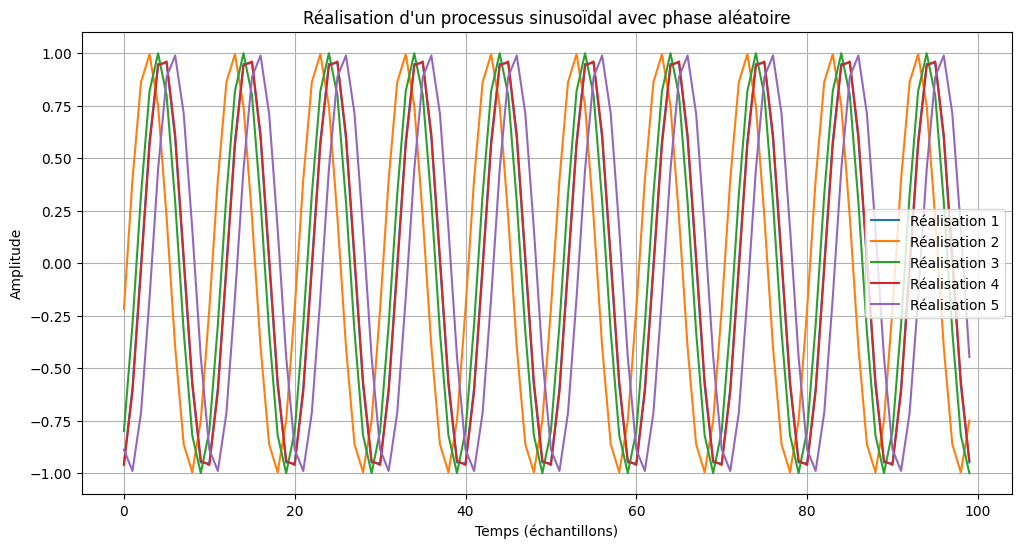

In [2]:
# Paramètres du processus
A = 1.0 # Amplitude
f0 = 0.1 # Fréquence normalisée (cycles par échantillon)
N = 100 # Nombre d'échantillons par réalisation
NR = 50 # Nombre de réalisations
# Fixer la graine pour la reproductibilité
np.random.seed(0)
# Générer des phases aléatoires uniformément distribuées entre 0 et 2π
phi = np.random.uniform(0, 2 * np.pi, NR)
# Générer les réalisations du processus
n = np.arange(N) # Vecteur de temps
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi) # Matrice de réalisations (N x NR)
# Afficher quelques réalisations
plt.figure(figsize=(12, 6))
for i in range(5): # Afficher les 5 premières réalisations
    plt.plot(n, X[:, i], label=f'Réalisation {i+1}')
plt.title('Réalisation d\'un processus sinusoïdal avec phase aléatoire')
plt.xlabel('Temps (échantillons)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

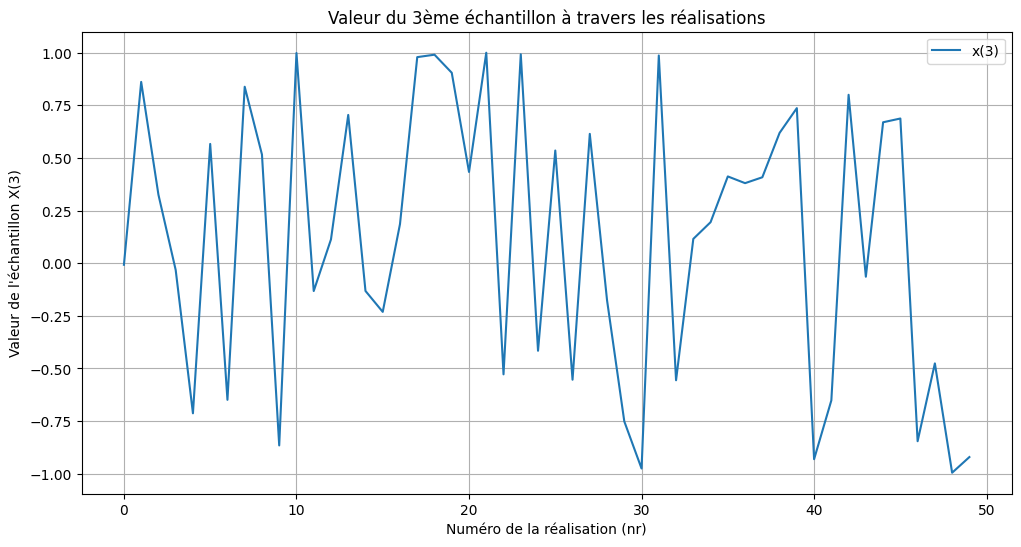

In [3]:
# Sélection du 3ème échantillon (index 2)
index_echantillon = 2

plt.figure(figsize=(12, 6))

# On trace la ligne correspondante dans la matrice X pour toutes les réalisations
plt.plot(X[index_echantillon, :], label='x(3)')

# Ajout des éléments visuels comme sur le modèle
plt.title('Valeur du 3ème échantillon à travers les réalisations')
plt.xlabel('Numéro de la réalisation (nr)')
plt.ylabel("Valeur de l'échantillon X(3)")
plt.legend()
plt.grid(True)
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_38758/1578324515.py:21: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title("Variance d'ensemble $\sigma_X^2(n)$")


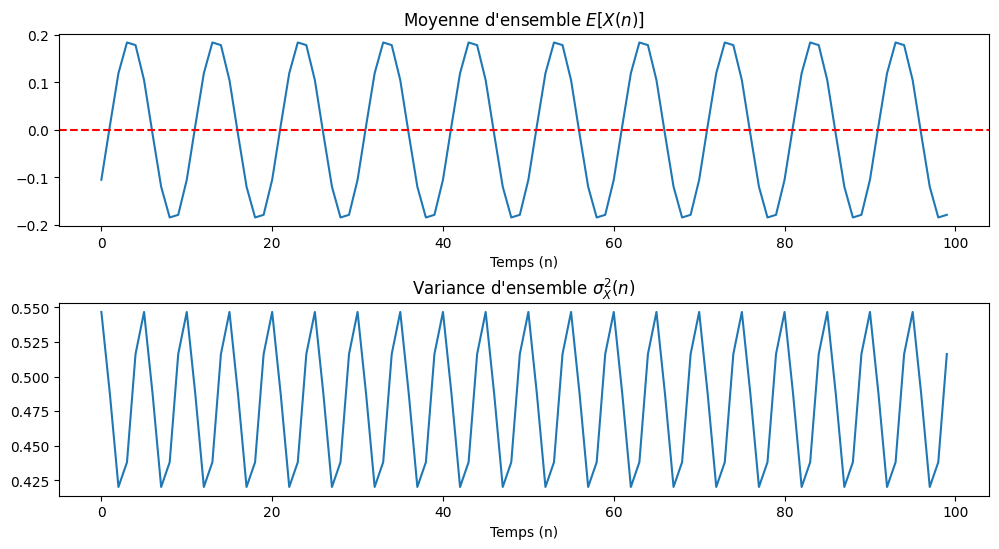

In [4]:
# 1. Calcul des statistiques d'ensemble
# Moyenne sur l'axe des réalisations (colonnes)
moyenne_ensemble = np.mean(X, axis=1) 

# Variance sur l'axe des réalisations (colonnes)
variance_ensemble = np.var(X, axis=1)

# 2. Création des graphiques
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.4) # Espace entre les deux graphiques

# --- Graphique 1 : Moyenne d'ensemble ---
ax1.plot(n, moyenne_ensemble)
ax1.axhline(y=0, color='r', linestyle='--') # Ligne rouge pointillée à 0
ax1.set_title("Moyenne d'ensemble $E[X(n)]$")
ax1.set_xlabel('Temps (n)')
# Selon la théorie, les réalisations s'annulent mutuellement, la moyenne doit osciller autour de 0.

# --- Graphique 2 : Variance d'ensemble ---
ax2.plot(n, variance_ensemble)
ax2.set_title("Variance d'ensemble $\sigma_X^2(n)$")
ax2.set_xlabel('Temps (n)')
# La puissance du signal étant répartie uniformément, la variance théorique est de A^2 / 2 (soit 0.5 si A=1).

plt.show()

Taille de la matrice Rx : (50, 50)
Exemple de valeurs dans Rx :
 [[ 1.          0.50158155  0.94309531  0.9996951   0.70640132]
 [ 0.50158155  1.          0.76070789  0.48006694 -0.25801723]
 [ 0.94309531  0.76070789  1.          0.93459697  0.4308405 ]
 [ 0.9996951   0.48006694  0.93459697  1.          0.72366352]
 [ 0.70640132 -0.25801723  0.4308405   0.72366352  1.        ]]
Diagonale pour k=0 : [1. 1. 1. 1. 1.]
Diagonale pour k=1 : [0.50158155 0.76070789 0.93459697 0.72366352 0.17354242]
Valeur moyenne de la diagonale k=1 : 0.10826446124639742


/home/david/dev/MA_StatDig/.venv/lib64/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/dev/MA_StatDig/.venv/lib64/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


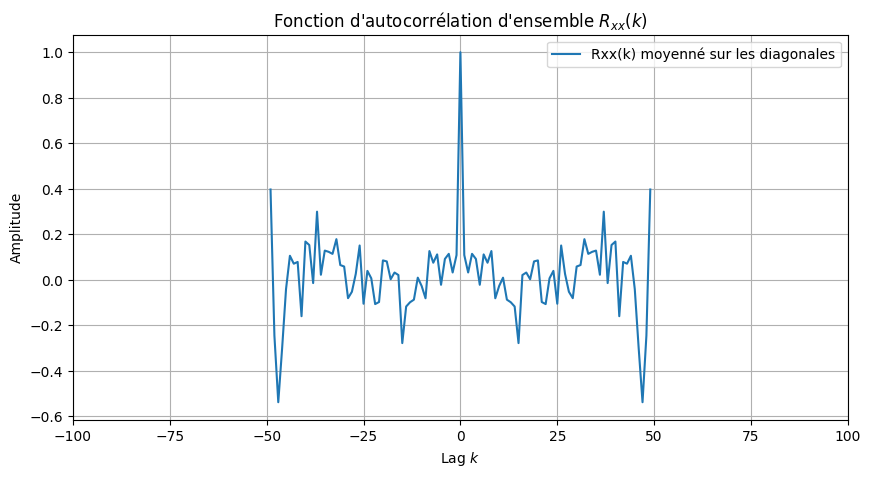

In [5]:
# X est la matrice (NR x N) générée précédemment
# Calcul de la matrice d'autocorrélation Rx (N x N)
# En Python: (1/NR) * X.T @ X
Rx = (1 / NR) * (X.T@ X) 

print(f"Taille de la matrice Rx : {Rx.shape}") # Doit être (1000, 1000)
print(f"Exemple de valeurs dans Rx :\n {Rx[:5, :5]}")
lags = np.arange(-(N - 1), N)
rxx_ensemble = np.zeros(len(lags))
print(f"Diagonale pour k=0 : {np.diag(Rx, k=0)[:5]}")
print(f"Diagonale pour k=1 : {np.diag(Rx, k=1)[:5]}")
print(f"Valeur moyenne de la diagonale k=1 : {np.mean(np.diag(Rx, k=1))}")

for i, k in enumerate(lags):
    diagonal = np.diag(Rx, k)
    rxx_ensemble[i] = np.mean(diagonal)
# 2. Visualisation du résultat
plt.figure(figsize=(10, 5))
plt.plot(lags, rxx_ensemble, label='Rxx(k) moyenné sur les diagonales')
plt.title('Fonction d\'autocorrélation d\'ensemble $R_{xx}(k)$')
plt.xlabel('Lag $k$')
plt.ylabel('Amplitude')
plt.grid(True)

plt.xlim([-100, 100]) # Zoom pour voir la structure
plt.legend()